In [4]:
# ============================================================
# U9 SETUP CELL (RUN FIRST)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# Create dataset if missing
# ------------------------------------------------------------

if not os.path.exists("ecommerce_customers.csv"):

    np.random.seed(42)

    n = 2500

    df_gen = pd.DataFrame({
        "customer_id": [f"CUST{i:05d}" for i in range(n)],
        "age": np.random.normal(38, 12, n).clip(18, 80),
        "num_orders": np.random.poisson(4, n),
        "total_spend": np.random.lognormal(5, 1, n),
        "support_tickets": np.random.poisson(1, n),
        "email_opt_in": np.random.choice([0,1], n, p=[0.35,0.65]),
        "plan": np.random.choice(
            ["Basic","Standard","Premium"],
            n,
            p=[0.5,0.35,0.15]
        ),
        "device": np.random.choice(
            ["Mobile","Desktop","Tablet"],
            n,
            p=[0.60,0.32,0.08]
        ),
        "payment_method": np.random.choice(
            ["Card","UPI","Wallet","NetBanking"],
            n
        ),
        "gender": np.random.choice(
            ["M","F","Other"],
            n,
            p=[0.48,0.48,0.04]
        ),
        "city": np.random.choice(
            ["Mumbai","Delhi","Pune","Hyderabad","Chennai"],
            n
        ),
        "is_churned": np.random.choice(
            [0,1],
            n,
            p=[0.8,0.2]
        )
    })

    df_gen.to_csv("ecommerce_customers.csv", index=False)

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

df = pd.read_csv("ecommerce_customers.csv")

print("Dataset Loaded")
print("Shape:", df.shape)

df.head()

Dataset Loaded
Shape: (2500, 12)


,customer_id,age,num_orders,total_spend,support_tickets,email_opt_in,plan,device,payment_method,gender,city,is_churned
0,CUST00000,43.960570,3,167.244477,1,1,Premium,Mobile,Wallet,F,Hyderabad,1
1,CUST00001,36.340828,4,487.453535,1,1,Basic,Mobile,Card,F,Mumbai,0
2,CUST00002,45.772262,7,197.781103,0,1,Standard,Desktop,UPI,M,Hyderabad,0
3,CUST00003,56.276358,4,103.892998,3,0,Basic,Mobile,Wallet,F,Hyderabad,0
4,CUST00004,35.190160,7,188.754552,3,1,Standard,Desktop,NetBanking,F,Delhi,0


In [5]:
# ============================================================
# LAB EXERCISE 1
# ============================================================

print("Customer IDs unique:",
      df["customer_id"].is_unique)

print("Duplicate IDs:",
      df["customer_id"].duplicated().sum())

print("\nNumeric Summary:")
print(df.describe())

Customer IDs unique: True
Duplicate IDs: 0

Numeric Summary:
               age   num_orders  total_spend  support_tickets  email_opt_in  \
count  2500.000000  2500.000000  2500.000000      2500.000000   2500.000000   
mean     38.595362     3.937200   247.819007         1.055200      0.650800   
std      11.373367     1.960304   302.757067         1.063864      0.476813   
min      18.000000     0.000000     2.548225         0.000000      0.000000   
25%      30.469506     3.000000    74.805575         0.000000      0.000000   
50%      38.317861     4.000000   154.609325         1.000000      1.000000   
75%      46.157028     5.000000   301.859704         2.000000      1.000000   
max      80.000000    13.000000  4027.785074         7.000000      1.000000   

        is_churned  
count  2500.000000  
mean      0.201200  
std       0.400977  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  


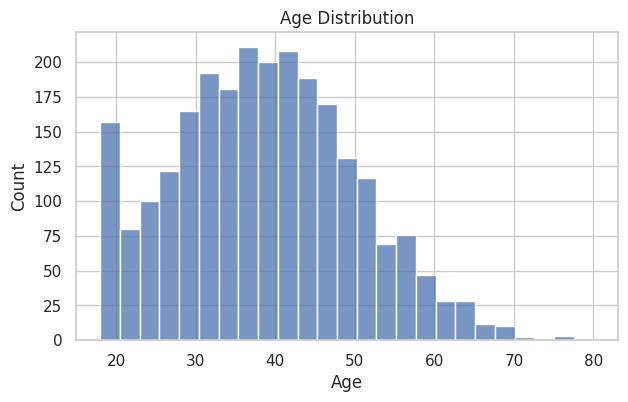

In [6]:
plt.figure(figsize=(7,4))

sns.histplot(
    df["age"].dropna(),
    bins=25
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [7]:
print("num_orders skew:",
      round(df["num_orders"].skew(),3))

print("total_spend skew:",
      round(df["total_spend"].skew(),3))

num_orders skew: 0.435
total_spend skew: 3.958


is_churned
0    0.7988
1    0.2012
Name: proportion, dtype: float64

Imbalance Ratio: 3.97


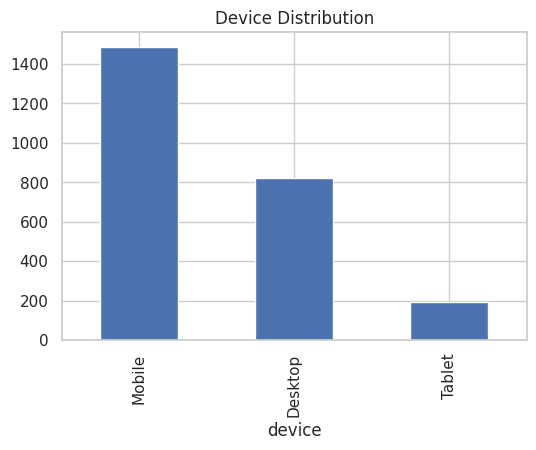

In [8]:
print(
    df["is_churned"]
    .value_counts(normalize=True)
)

retained = (df["is_churned"]==0).sum()
churned = (df["is_churned"]==1).sum()

print(
    "\nImbalance Ratio:",
    round(retained/churned,2)
)

plt.figure(figsize=(6,4))

df["device"].value_counts().plot(kind="bar")

plt.title("Device Distribution")
plt.show()

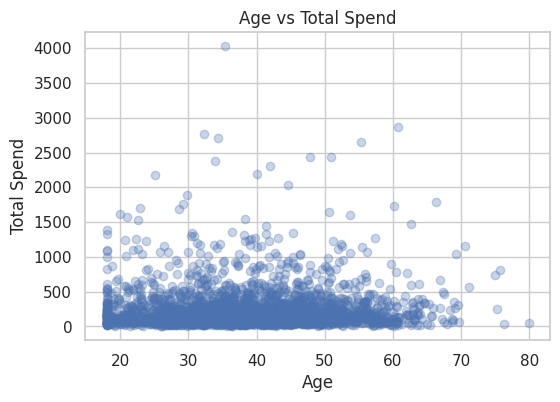

Correlation: 0.027


In [9]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["age"],
    df["total_spend"],
    alpha=0.3
)

plt.xlabel("Age")
plt.ylabel("Total Spend")
plt.title("Age vs Total Spend")
plt.show()

print(
    "Correlation:",
    round(
        df["age"].corr(df["total_spend"]),
        3
    )
)

is_churned
0    1.074111
1    0.980119
Name: support_tickets, dtype: float64


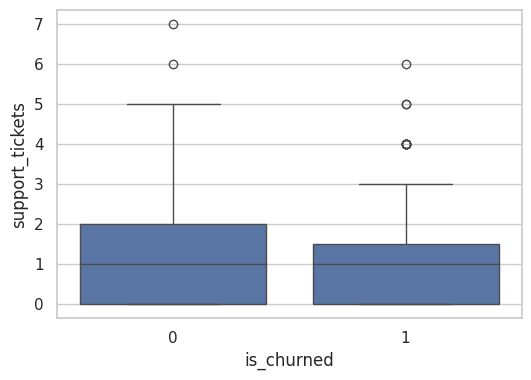

In [10]:
print(
    df.groupby("is_churned")
      ["support_tickets"]
      .mean()
)

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="is_churned",
    y="support_tickets"
)

plt.show()

In [11]:
num_cols = [
    "age",
    "num_orders",
    "total_spend",
    "support_tickets",
    "email_opt_in",
    "is_churned"
]

corr = df[num_cols].corr()

top2 = (
    corr["is_churned"]
    .drop("is_churned")
    .abs()
    .sort_values(ascending=False)
    .head(2)
)

print(top2)

total_spend    0.046106
num_orders     0.037373
Name: is_churned, dtype: float64


In [12]:
print(
    "Spend Skew:",
    round(df["total_spend"].skew(),3)
)

print(
    "Churn Rate:",
    round(df["is_churned"].mean(),3)
)

missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print("\nMissing %:")
print(missing)

print(
    "\nHighest Missing Column:",
    missing.idxmax()
)

Spend Skew: 3.958
Churn Rate: 0.201

Missing %:
customer_id        0.0
age                0.0
num_orders         0.0
total_spend        0.0
support_tickets    0.0
email_opt_in       0.0
plan               0.0
device             0.0
payment_method     0.0
gender             0.0
city               0.0
is_churned         0.0
dtype: float64

Highest Missing Column: customer_id
